In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.config import DATASETS, console
from rich.table import Table

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

console.rule(f"[bold red]EDA: {dataset_name.upper()}")
console.print(f"Cargando datos desde: [path]{config['raw_path']}[/path]\n")

───────────────────────────────────────────────── EDA: EDGE_IIOT ──────────────────────────────────────────────────

Cargando datos desde: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot

In [2]:
# Construimos la ruta al CSV específico dentro de la carpeta raw
csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / "ML-EdgeIIoT-dataset.csv"

with console.status("[bold green]Cargando CSV...[/bold green]"):
    df = pd.read_csv(csv_path, low_memory=False)
    
console.print(f"[bold success]✓[/bold success] Dataset cargado: [bold cyan]{df.shape[0]}[/bold cyan] filas y [bold cyan]{df.shape[1]}[/bold cyan] columnas.")

/home/uo294319/ML-NIDS-IIoT/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ Dataset cargado: 157800 filas y 63 columnas.

In [19]:
def summarize_df(df, n=5, i=0, ncol=7):
    table = Table(title=f"Primeras {n} filas del Dataset")
    
    # Añadimos columnas (solo las primeras 6 para no saturar la pantalla)
    cols_to_show = df.columns[i:i+ncol]
    for col in cols_to_show:
        table.add_column(col, style="magenta")
    
    for _, row in df.head(n).iterrows():
        table.add_row(*[str(row[c]) for c in cols_to_show])
    
    console.print(table)

for i in range(0, df.shape[1], 7):
    summarize_df(df, n=5, i=i, ncol=7)

                                          Primeras 5 filas del Dataset                                           
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ frame.time ┃ ip.src_host   ┃ ip.dst_host ┃ arp.dst.proto_ipv4 ┃ arp.opcode ┃ arp.hw.size ┃ arp.src.proto_ipv4 ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ 6.0        │ 192.168.0.152 │ 0.0         │ 0.0                │ 0.0        │ 0.0         │ 0.0                │
│ 6.0        │ 192.168.0.101 │ 0.0         │ 0.0                │ 0.0        │ 0.0         │ 0.0                │
│ 6.0        │ 192.168.0.152 │ 0.0         │ 0.0                │ 0.0        │ 0.0         │ 0.0                │
│ 6.0        │ 192.168.0.101 │ 0.0         │ 0.0                │ 0.0        │ 0.0         │ 0.0                │
│ 6.0        │ 192.168.0.152 │ 0.0         │ 0.0                │ 0.0        │ 0.0         │ 0.0                │
└────────────┴───────────────┴─────────────┴────────────────────┴────────────┴─────────────┴────────────────────┘

                                           Primeras 5 filas del Dataset                                            
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ icmp.checksum ┃ icmp.seq_le ┃ icmp.transmit_… ┃ icmp.unused ┃ http.file_data ┃ http.content_l… ┃ http.request.… ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ 0.0           │ 0.0         │ 0.0             │ 0.0         │ 0.0            │ 0.0             │ 0.0            │
│ 0.0           │ 0.0         │ 0.0             │ 0.0         │ 0.0            │ 0.0             │ 0.0            │
│ 0.0           │ 0.0         │ 0.0             │ 0.0         │ 0.0            │ 0.0             │ 0.0            │
│ 0.0           │ 0.0         │ 0.0             │ 0.0         │ 0.0            │ 0.0             │ 0.0            │
│ 0.0           │ 0.0         │ 0.0             │ 0.0         │ 0.0            │ 0.0             │ 0.0            │
└───────────────┴─────────────┴─────────────────┴─────────────┴────────────────┴─────────────────┴────────────────┘

                                           Primeras 5 filas del Dataset                                            
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ http.request.me… ┃ http.referer ┃ http.request.fu… ┃ http.request.ve… ┃ http.response ┃ http.tls_port ┃ tcp.ack ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ 0.0              │ 0.0          │ 0.0              │ 0                │ 0.0           │ 0.0           │ 0.0     │
│ 0.0              │ 0.0          │ 0.0              │ 0                │ 0.0           │ 0.0           │ 0.0     │
│ 0.0              │ 0.0          │ 0.0              │ 0                │ 0.0           │ 0.0           │ 0.0     │
│ 0.0              │ 0.0          │ 0.0              │ 0                │ 0.0           │ 0.0           │ 0.0     │
│ 0.0              │ 0.0          │ 0.0              │ 0                │ 0.0           │ 0.0           │ 0.0     │
└──────────────────┴──────────────┴──────────────────┴──────────────────┴───────────────┴───────────────┴─────────┘

                                           Primeras 5 filas del Dataset                                            
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ tcp.ack_raw ┃ tcp.checksum ┃ tcp.connection… ┃ tcp.connection… ┃ tcp.connectio… ┃ tcp.connection… ┃ tcp.dstport ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0.0         │ 0.0          │ 0.0             │ 0.0             │ 0.0            │ 0.0             │ 0.0         │
│ 0.0         │ 0.0          │ 0.0             │ 0.0             │ 0.0            │ 0.0             │ 0.0         │
│ 0.0         │ 0.0          │ 0.0             │ 0.0             │ 0.0            │ 0.0             │ 0.0         │
│ 0.0         │ 0.0          │ 0.0             │ 0.0             │ 0.0            │ 0.0             │ 0.0         │
│ 0.0         │ 0.0          │ 0.0             │ 0.0             │ 0.0            │ 0.0             │ 0.0         │
└─────────────┴──────────────┴─────────────────┴─────────────────┴────────────────┴─────────────────┴─────────────┘

                               Primeras 5 filas del Dataset                                
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ tcp.flags ┃ tcp.flags.ack ┃ tcp.len ┃ tcp.options ┃ tcp.payload ┃ tcp.seq ┃ tcp.srcport ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0.0       │ 0.0           │ 0.0     │ 0.0         │ 0.0         │ 0.0     │ 0           │
│ 0.0       │ 0.0           │ 0.0     │ 0.0         │ 0.0         │ 0.0     │ 0           │
│ 0.0       │ 0.0           │ 0.0     │ 0.0         │ 0.0         │ 0.0     │ 0           │
│ 0.0       │ 0.0           │ 0.0     │ 0.0         │ 0.0         │ 0.0     │ 0           │
│ 0.0       │ 0.0           │ 0.0     │ 0.0         │ 0.0         │ 0.0     │ 0           │
└───────────┴───────────────┴─────────┴─────────────┴─────────────┴─────────┴─────────────┘

                                      Primeras 5 filas del Dataset                                      
┏━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ udp.port ┃ udp.stream ┃ udp.time_delta ┃ dns.qry.name ┃ dns.qry.name.len ┃ dns.qry.qu ┃ dns.qry.type ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 0.0      │ 0.0        │ 0.0            │ 0.0          │ 0.0              │ 0.0        │ 0.0          │
│ 0.0      │ 0.0        │ 0.0            │ 0.0          │ 0.0              │ 0.0        │ 0.0          │
│ 0.0      │ 0.0        │ 0.0            │ 0.0          │ 0.0              │ 0.0        │ 0.0          │
│ 0.0      │ 0.0        │ 0.0            │ 0.0          │ 0.0              │ 0.0        │ 0.0          │
│ 0.0      │ 0.0        │ 0.0            │ 0.0          │ 0.0              │ 0.0        │ 0.0          │
└──────────┴────────────┴────────────────┴──────────────┴──────────────────┴────────────┴──────────────┘

                                           Primeras 5 filas del Dataset                                            
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ dns.retransm… ┃ dns.retransm… ┃ dns.retransmi… ┃ mqtt.conack.… ┃ mqtt.conflag.… ┃ mqtt.conflags ┃ mqtt.hdrflags ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0.0           │ 0.0           │ 0.0            │ 0.0           │ 0.0            │ 0.0           │ 0.0           │
│ 0.0           │ 0.0           │ 0.0            │ 0.0           │ 0.0            │ 0.0           │ 0.0           │
│ 0.0           │ 0.0           │ 0.0            │ 0.0           │ 0.0            │ 0.0           │ 0.0           │
│ 0.0           │ 0.0           │ 0.0            │ 0.0           │ 0.0            │ 0.0           │ 0.0           │
│ 0.0           │ 0.0           │ 0.0            │ 0.0           │ 0.0            │ 0.0           │ 0.0           │
└───────────────┴───────────────┴────────────────┴───────────────┴────────────────┴───────────────┴───────────────┘

                                       Primeras 5 filas del Dataset                                        
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ mqtt.len ┃ mqtt.msg_decoded_as ┃ mqtt.msg ┃ mqtt.msgtype ┃ mqtt.proto_len ┃ mqtt.protoname ┃ mqtt.topic ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ 0.0      │ 0.0                 │ 0.0      │ 0.0          │ 0.0            │ 0.0            │ 0.0        │
│ 0.0      │ 0.0                 │ 0.0      │ 0.0          │ 0.0            │ 0.0            │ 0.0        │
│ 0.0      │ 0.0                 │ 0.0      │ 0.0          │ 0.0            │ 0.0            │ 0.0        │
│ 0.0      │ 0.0                 │ 0.0      │ 0.0          │ 0.0            │ 0.0            │ 0.0        │
│ 0.0      │ 0.0                 │ 0.0      │ 0.0          │ 0.0            │ 0.0            │ 0.0        │
└──────────┴─────────────────────┴──────────┴──────────────┴────────────────┴────────────────┴────────────┘

                                     Primeras 5 filas del Dataset                                      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ mqtt.topic_len ┃ mqtt.ver ┃ mbtcp.len ┃ mbtcp.trans_id ┃ mbtcp.unit_id ┃ Attack_label ┃ Attack_type ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0.0            │ 0.0      │ 0.0       │ 0.0            │ 0.0           │ 1            │ MITM        │
│ 0.0            │ 0.0      │ 0.0       │ 0.0            │ 0.0           │ 1            │ MITM        │
│ 0.0            │ 0.0      │ 0.0       │ 0.0            │ 0.0           │ 1            │ MITM        │
│ 0.0            │ 0.0      │ 0.0       │ 0.0            │ 0.0           │ 1            │ MITM        │
│ 0.0            │ 0.0      │ 0.0       │ 0.0            │ 0.0           │ 1            │ MITM        │
└────────────────┴──────────┴───────────┴────────────────┴───────────────┴──────────────┴─────────────┘

In [4]:
console.print("\n[bold]Resumen de Calidad de Datos:[/bold]")

quality_table = Table(show_header=True, header_style="bold blue")
quality_table.add_column("Columna")
quality_table.add_column("Tipo")
quality_table.add_column("Nulos", justify="right")
quality_table.add_column("% Nulos", justify="right")

for col in df.columns[:10]: # Ejemplo con las primeras 10
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    color = "red" if null_count > 0 else "green"
    
    quality_table.add_row(
        col, 
        str(df[col].dtype), 
        f"[{color}]{null_count}[/{color}]", 
        f"[{color}]{null_pct:.2f}%[/{color}]"
    )

console.print(quality_table)

Resumen de Calidad de Datos:

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓
┃ Columna                 ┃ Tipo    ┃ Nulos ┃ % Nulos ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩
│ frame.time              │ str     │     0 │   0.00% │
│ ip.src_host             │ str     │     0 │   0.00% │
│ ip.dst_host             │ str     │     0 │   0.00% │
│ arp.dst.proto_ipv4      │ str     │     0 │   0.00% │
│ arp.opcode              │ float64 │     0 │   0.00% │
│ arp.hw.size             │ float64 │     0 │   0.00% │
│ arp.src.proto_ipv4      │ str     │     0 │   0.00% │
│ icmp.checksum           │ float64 │     0 │   0.00% │
│ icmp.seq_le             │ float64 │     0 │   0.00% │
│ icmp.transmit_timestamp │ float64 │     0 │   0.00% │
└─────────────────────────┴─────────┴───────┴─────────┘

In [5]:
df.describe()

,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.content_length,http.response,http.tls_port,tcp.ack,...,mqtt.len,mqtt.msg_decoded_as,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label
count,157800.000000,157800.000000,157800.000000,157800.000000,1.578000e+05,157800.0,157800.000000,157800.000000,157800.0,1.578000e+05,...,157800.000000,157800.0,157800.000000,157800.000000,157800.000000,157800.000000,157800.0,157800.0,157800.0,157800.000000
mean,0.014195,0.059848,3047.291838,3239.979778,4.046816e+04,0.0,14.715520,0.045748,0.0,7.160039e+07,...,0.419341,0.0,0.161331,0.031686,0.189506,0.031686,0.0,0.0,0.0,0.846001
std,0.149783,0.596245,11144.328203,11406.072994,1.764075e+06,0.0,229.659671,0.208938,0.0,3.101231e+08,...,3.606594,0.0,1.293453,0.354598,2.124206,0.354598,0.0,0.0,0.0,0.360949
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,1.000000e+00,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,4.790000e+02,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000
max,2.000000,6.000000,65532.000000,65524.000000,7.728902e+07,0.0,83655.000000,1.000000,0.0,2.147333e+09,...,39.000000,0.0,14.000000,4.000000,24.000000,4.000000,0.0,0.0,0.0,1.000000


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_label_distribution(df_data, label_col):
    # 1. Preparación de datos
    conteo = df_data[label_col].value_counts()
    labels = conteo.index
    sizes = conteo.values

    # 2. DEFINICIÓN DE COLORES (El cambio clave)
    palette_colors = sns.color_palette("viridis", len(labels))

    # Creamos un diccionario {Etiqueta: Color} para asegurar consistencia
    color_map = dict(zip(labels, palette_colors))

    explode = [0.05] * len(labels)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # --- GRÁFICO 1: Barras ---
    sns.countplot(y=label_col,
                  data=df_data,
                  ax=ax1,
                  order=labels,
                  hue=label_col,
                  palette=color_map,  # Mapeo fijo de colores
                  legend=False)       # Ocultar leyenda

    ax1.set_title(f"Count of each {label_col}")
    ax1.set_xlabel("Count")
    ax1.set_ylabel(label_col)

    # --- GRÁFICO 2: Donut (Pie) ---
    pie_colors = [color_map[label] for label in labels]

    ax2.pie(sizes,
            explode=explode,
            labels=labels,
            autopct='%1.1f%%',
            startangle=60,
            pctdistance=0.85,
            colors=pie_colors) # <--- AQUÍ usamos los colores del mismo mapeo

    center_circle = plt.Circle((0,0), 0.70, fc='white')
    ax2.add_artist(center_circle)

    ax2.set_title(f"Percentage of each {label_col}")

    plt.tight_layout()
    plt.show()

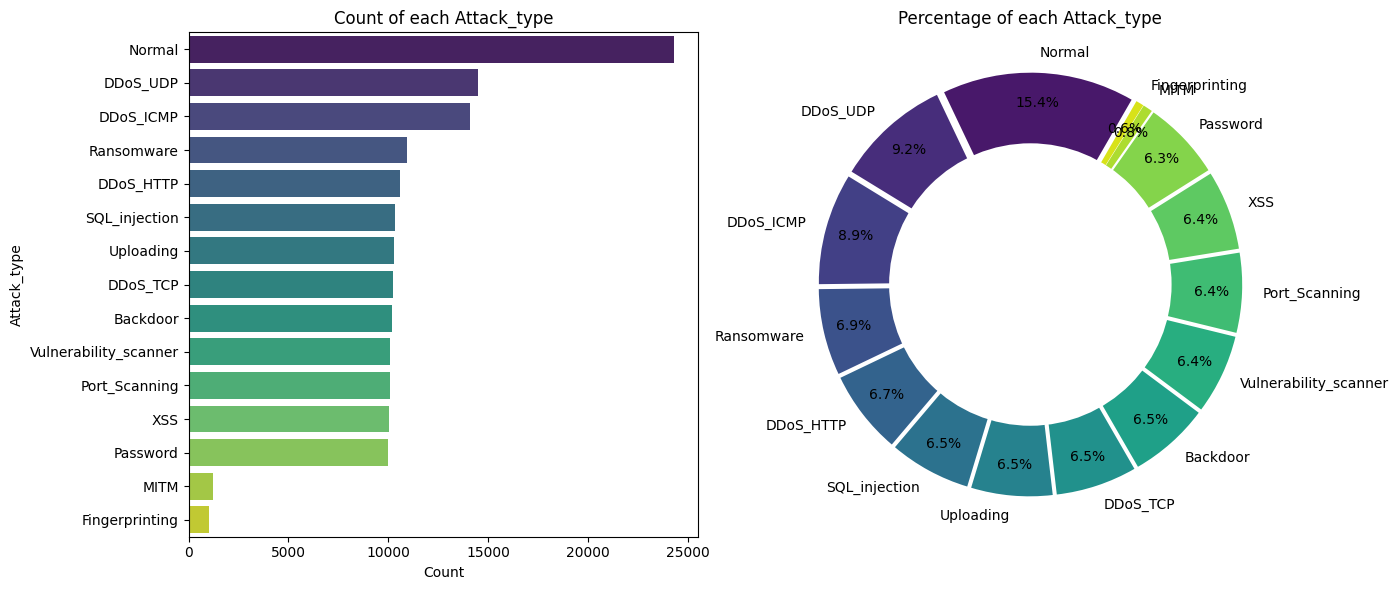

In [7]:
label_col = "Attack_type"
plot_label_distribution(df, label_col)

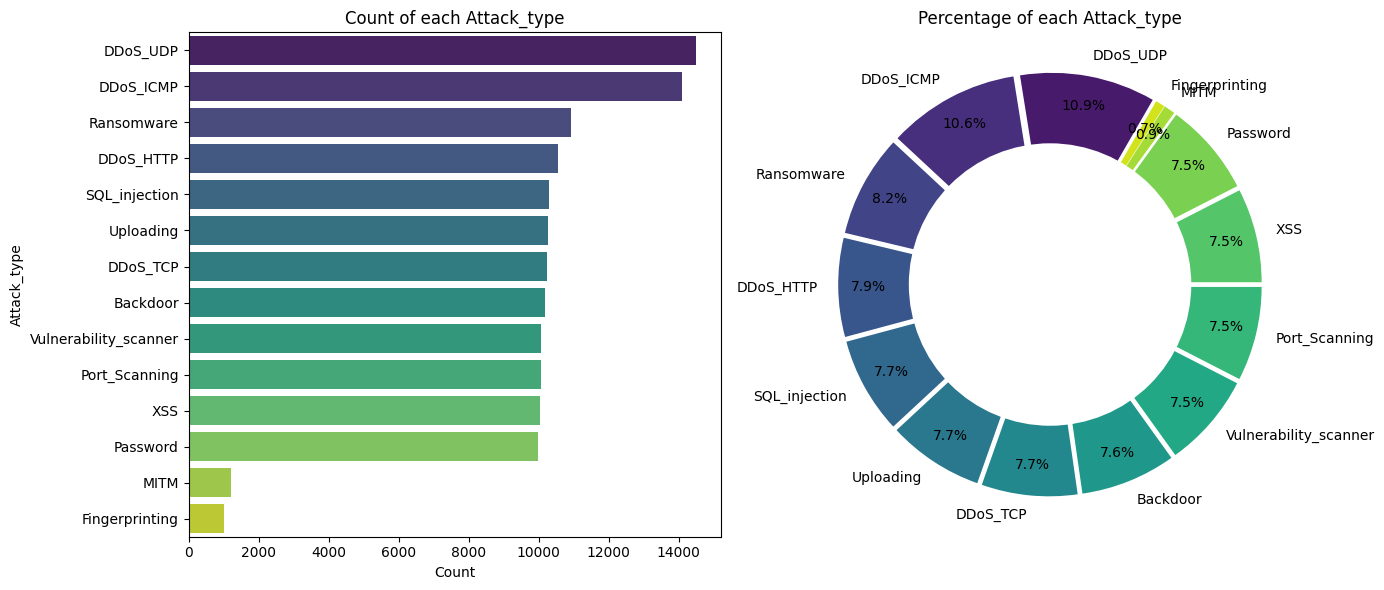

In [8]:
df_no_normal = df[df[label_col] != 'Normal']
plot_label_distribution(df_no_normal, label_col)